# Feature feasibility learning curves

This notebook studies feature-based feasibility estimation as a learning-curve problem. We keep a fixed test split, fit `FeasibilityEstimatorFeatureCannotExist` on increasingly large training subsets, and count how many test graphs are judged infeasible because they contain previously unseen features.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split

from abstractgraph.operators import neighborhood
from abstractgraph_ml.feasibility import FeasibilityEstimatorFeatureCannotExist
from abstractgraph_graphicalizer.chem import ZINCLoader


## Dataset

We use ZINC as a convenient source of many molecular graphs. The notebook loads from `abstractgraph-graphicalizer/data-local/ZINC` explicitly.


In [3]:
zinc_root = workspace_root / "abstractgraph-graphicalizer" / "data-local" / "ZINC"
loader = ZINCLoader(zinc_root, on_error="skip")
dataset_name = "zinc_250k"
limit = 4000
max_node_count = 25

graphs, metadata = loader.load(dataset_name, limit=limit, max_node_count=max_node_count)

print("root:", loader.root)
print("dataset_name:", dataset_name)
print("graphs loaded:", len(graphs))
display(metadata.head())


root: /home/fabrizio/code/abstractgraph-ecosystem/repos/abstractgraph-graphicalizer/data-local/ZINC
dataset_name: zinc_250k
graphs loaded: 4000


,smiles,logP,qed,SAS,_zinc_row_index
0,C=C(Br)CON\n,0.7853,0.602918,3.834174,44328
1,Br[C@H]1CC[NH2+]C1\n,-0.2830,0.474086,6.467389,70676
2,C/C(I)=C/CI\n,2.7602,0.513224,4.340924,223007
3,Cl/C=C/C(Cl)(Cl)Cl\n,3.1091,0.495470,4.165780,41626
4,O[C@@H](CBr)C1CC1\n,1.1522,0.615928,3.383327,80640


## Fixed train/test split

We reserve a fixed fraction of graphs for testing. The test set stays unchanged for the whole experiment; only the training subset size varies.


In [4]:
test_fraction = 0.25
random_state = 0

graph_indices = np.arange(len(graphs))
train_indices, test_indices = train_test_split(
    graph_indices,
    test_size=test_fraction,
    random_state=random_state,
    shuffle=True,
)

train_pool = [graphs[idx] for idx in train_indices]
test_graphs = [graphs[idx] for idx in test_indices]

print("train pool size:", len(train_pool))
print("test size:", len(test_graphs))


train pool size: 3000
test size: 1000


## Feature feasibility estimators

Each estimator forbids features that never appeared in the observed training subset. We compare several decomposition granularities, which act as different feature vocabularies.


In [7]:
from abstractgraph.operators import *
estimator_specs = [
    ("cycle", cycle()),
    ("radius_1", neighborhood(radius=1)),
    ("radius_2", neighborhood(radius=2)),
    ("combination_cycle_unlabel", compose(combination(number_of_elements=(2,3), distance=0), cycle(), unlabel())),
]

nbits = 14
n_sampled_training_sets = 2
train_sizes = [25, 50, 100, 200, 400, 800, 1600]
train_sizes = [size for size in train_sizes if size < len(train_pool)]

pd.DataFrame(
    {
        "estimator_name": [name for name, _ in estimator_specs],
        "nbits": nbits,
    }
)


,estimator_name,nbits
0,cycle,14
1,radius_1,14
2,radius_2,14
3,combination_cycle_unlabel,14


## Run the learning-curve experiment

For each training size and each base estimator, we sample several different random training subsets from the same train pool, fit the deterministic feasibility estimator on each subset, and count infeasible test instances. With more observed training graphs, the number of unseen-forbidden features on the test set should generally go down.


In [9]:
rng = np.random.default_rng(random_state)
records = []
total_runs = len(estimator_specs) * len(train_sizes) * n_sampled_training_sets
run_index = 0

for estimator_name, decomposition_function in estimator_specs:
    print(f"\nEstimator: {estimator_name}")
    stop_larger_sizes = False
    for train_size_index, train_size in enumerate(train_sizes):
        if stop_larger_sizes:
            break
        print(f"  train_size={train_size}")
        current_size_records = []
        for sample_id in range(n_sampled_training_sets):
            run_index += 1
            print(
                f"    run {run_index}/{total_runs}: "
                f"sampled_training_set={sample_id + 1}/{n_sampled_training_sets} ...",
                flush=True,
            )
            subset_indices = rng.choice(len(train_pool), size=train_size, replace=False)
            train_graphs = [train_pool[idx] for idx in subset_indices]

            feasibility_estimator = FeasibilityEstimatorFeatureCannotExist(
                decomposition_function=decomposition_function,
                nbits=nbits,
                parallel=True,
            )
            feasibility_estimator.fit(train_graphs)

            feasible_mask = np.asarray(feasibility_estimator.predict(test_graphs)).astype(bool)
            infeasible_mask = np.logical_not(feasible_mask)
            violation_count = np.asarray(feasibility_estimator.number_of_violations(test_graphs)).astype(int)

            n_infeasible = int(infeasible_mask.sum())
            total_violations = int(violation_count.sum())

            print(
                f"      infeasible_test_graphs={n_infeasible} "
                f"total_violations={total_violations}",
                flush=True,
            )

            record = {
                "estimator_name": estimator_name,
                "train_size": train_size,
                "sample_id": sample_id,
                "test_size": len(test_graphs),
                "n_infeasible_test_graphs": n_infeasible,
                "fraction_infeasible_test_graphs": float(infeasible_mask.mean()),
                "total_forbidden_feature_violations": total_violations,
                "mean_forbidden_feature_violations": float(violation_count.mean()),
            }
            current_size_records.append(record)
            records.append(record)

        if max(record["n_infeasible_test_graphs"] for record in current_size_records) == 0:
            print("    all sampled training sets reached zero infeasible test graphs; skipping larger sizes", flush=True)
            for remaining_train_size in train_sizes[train_size_index + 1:]:
                for sample_id in range(n_sampled_training_sets):
                    records.append(
                        {
                            "estimator_name": estimator_name,
                            "train_size": remaining_train_size,
                            "sample_id": sample_id,
                            "test_size": len(test_graphs),
                            "n_infeasible_test_graphs": 0,
                            "fraction_infeasible_test_graphs": 0.0,
                            "total_forbidden_feature_violations": 0,
                            "mean_forbidden_feature_violations": 0.0,
                        }
                    )
            stop_larger_sizes = True

results = pd.DataFrame(records)
results.head()



Estimator: cycle
  train_size=25
    run 1/56: sampled_training_set=1/2 ...
      infeasible_test_graphs=412 total_violations=2533
    run 2/56: sampled_training_set=2/2 ...
      infeasible_test_graphs=379 total_violations=2316
  train_size=50
    run 3/56: sampled_training_set=1/2 ...
      infeasible_test_graphs=240 total_violations=1416
    run 4/56: sampled_training_set=2/2 ...
      infeasible_test_graphs=179 total_violations=1063
  train_size=100
    run 5/56: sampled_training_set=1/2 ...
      infeasible_test_graphs=148 total_violations=841
    run 6/56: sampled_training_set=2/2 ...
      infeasible_test_graphs=183 total_violations=1062
  train_size=200
    run 7/56: sampled_training_set=1/2 ...
      infeasible_test_graphs=126 total_violations=748
    run 8/56: sampled_training_set=2/2 ...
      infeasible_test_graphs=93 total_violations=554
  train_size=400
    run 9/56: sampled_training_set=1/2 ...
      infeasible_test_graphs=59 total_violations=344
    run 10/56: sampled_

,estimator_name,train_size,sample_id,test_size,n_infeasible_test_graphs,fraction_infeasible_test_graphs,total_forbidden_feature_violations,mean_forbidden_feature_violations
0,cycle,25,0,1000,412,0.412,2533,2.533
1,cycle,25,1,1000,379,0.379,2316,2.316
2,cycle,50,0,1000,240,0.240,1416,1.416
3,cycle,50,1,1000,179,0.179,1063,1.063
4,cycle,100,0,1000,148,0.148,841,0.841


In [10]:
summary = (
    results.groupby(["estimator_name", "train_size"], as_index=False)
    .agg(
        mean_infeasible_test_graphs=("n_infeasible_test_graphs", "mean"),
        std_infeasible_test_graphs=("n_infeasible_test_graphs", "std"),
        mean_fraction_infeasible=("fraction_infeasible_test_graphs", "mean"),
        mean_total_violations=("total_forbidden_feature_violations", "mean"),
    )
)
display(summary)


,estimator_name,train_size,mean_infeasible_test_graphs,std_infeasible_test_graphs,mean_fraction_infeasible,mean_total_violations
0,combination_cycle_unlabel,25,72.5,44.547727,0.0725,735.5
1,combination_cycle_unlabel,50,52.0,16.970563,0.0520,561.5
2,combination_cycle_unlabel,100,26.5,2.121320,0.0265,307.0
3,combination_cycle_unlabel,200,31.5,6.363961,0.0315,344.0
4,combination_cycle_unlabel,400,16.0,2.828427,0.0160,223.5
5,combination_cycle_unlabel,800,8.0,2.828427,0.0080,141.5
6,combination_cycle_unlabel,1600,6.0,0.000000,0.0060,117.0
7,cycle,25,395.5,23.334524,0.3955,2424.5
8,cycle,50,209.5,43.133514,0.2095,1239.5
9,cycle,100,165.5,24.748737,0.1655,951.5


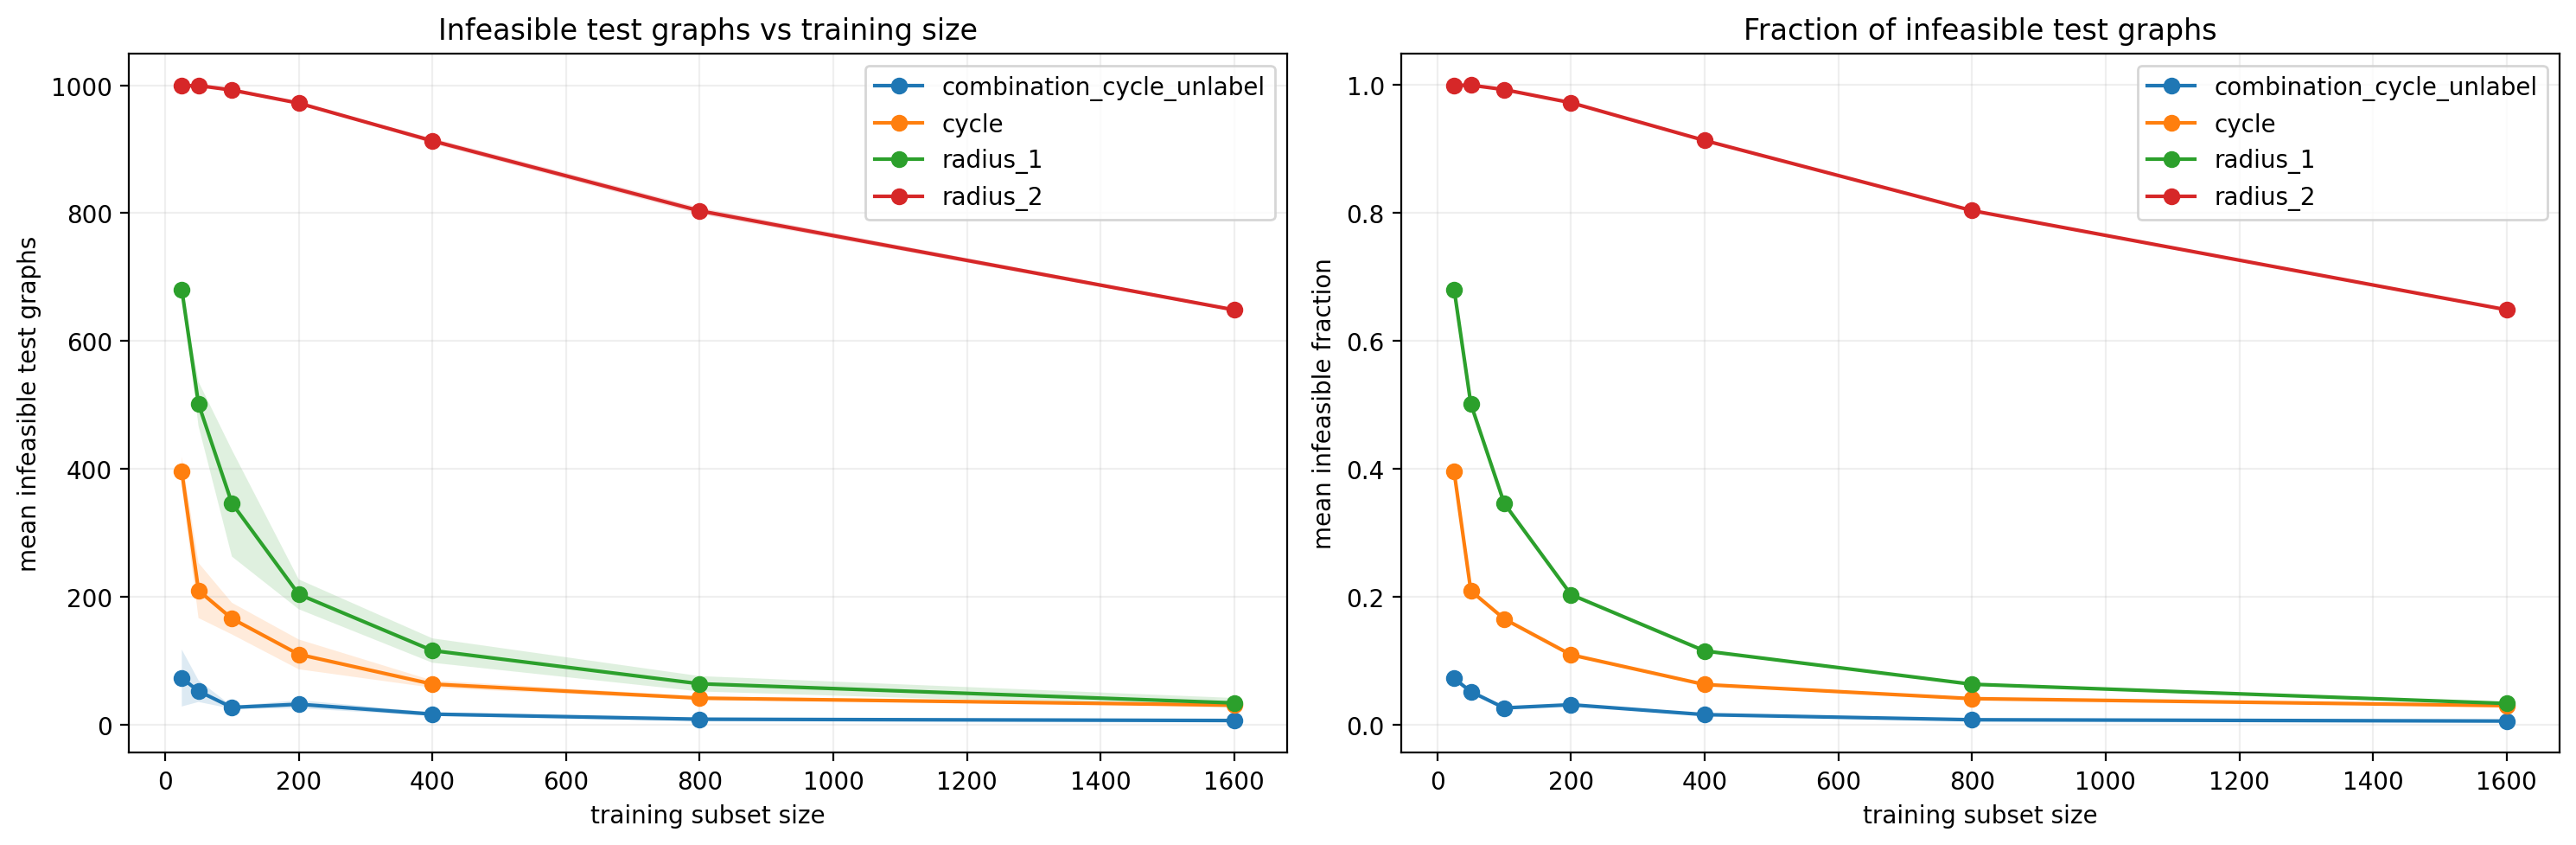

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for estimator_name in summary["estimator_name"].unique():
    subset = summary[summary["estimator_name"] == estimator_name].sort_values("train_size")
    x = subset["train_size"].to_numpy()
    y = subset["mean_infeasible_test_graphs"].to_numpy()
    y_log = np.log1p(y)
    yerr = np.nan_to_num(subset["std_infeasible_test_graphs"].to_numpy(), nan=0.0)
    y_lower_log = np.log1p(np.clip(y - yerr, a_min=0.0, a_max=None))
    y_upper_log = np.log1p(np.clip(y + yerr, a_min=0.0, a_max=None))

    axes[0].plot(x, y_log, marker="o", label=estimator_name)
    axes[0].fill_between(x, y_lower_log, y_upper_log, alpha=0.15)

    axes[1].plot(
        x,
        subset["mean_fraction_infeasible"].to_numpy(),
        marker="o",
        label=estimator_name,
    )

axes[0].set_title("Infeasible test graphs vs training size")
axes[0].set_xlabel("training subset size")
axes[0].set_ylabel("log(1 + mean infeasible test graphs)")
axes[0].grid(alpha=0.2)

axes[1].set_title("Fraction of infeasible test graphs")
axes[1].set_xlabel("training subset size")
axes[1].set_ylabel("mean infeasible fraction")
axes[1].grid(alpha=0.2)

axes[0].legend(loc="best")
axes[1].legend(loc="best")
plt.tight_layout()


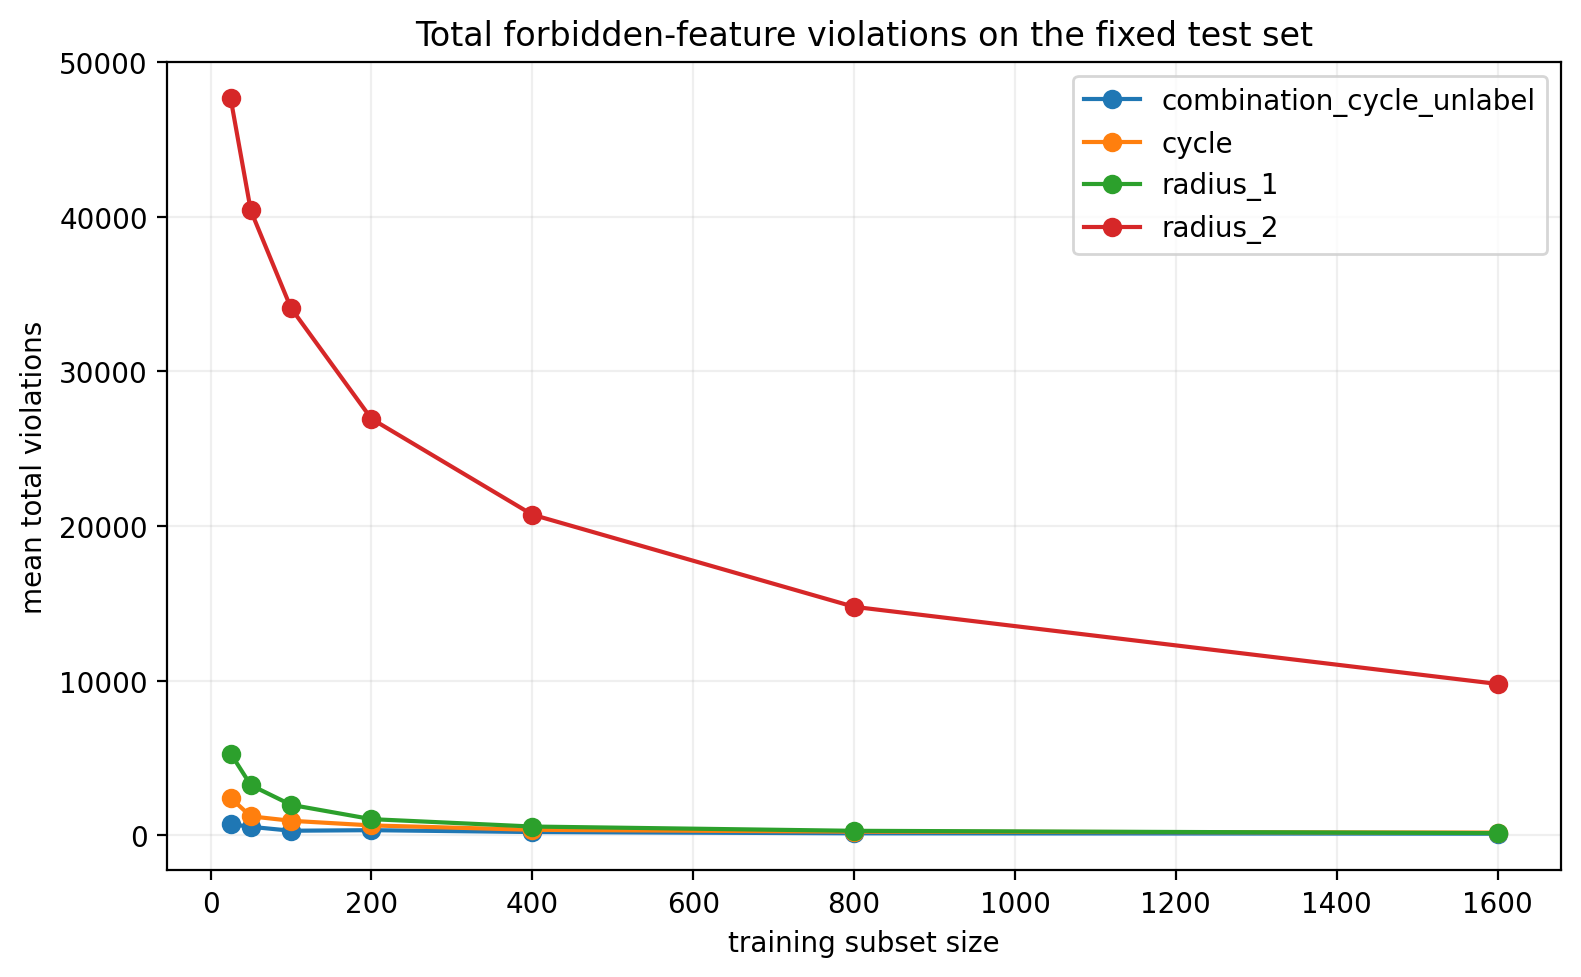

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

for estimator_name in summary["estimator_name"].unique():
    subset = summary[summary["estimator_name"] == estimator_name].sort_values("train_size")
    ax.plot(
        subset["train_size"],
        subset["mean_total_violations"],
        marker="o",
        label=estimator_name,
    )

ax.set_title("Total forbidden-feature violations on the fixed test set")
ax.set_xlabel("training subset size")
ax.set_ylabel("mean total violations")
ax.grid(alpha=0.2)
ax.legend(loc="best")
plt.tight_layout()
